In [27]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
 
print("Libraries loaded!")
print(f"PyTorch version: {torch.__version__}")

Libraries loaded!
PyTorch version: 2.10.0+cu128


In [28]:
BASE_DIR = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'
df = pd.read_csv(f'{BASE_DIR}/HAM10000_metadata.csv')

img_dir_1 = f'{BASE_DIR}/HAM10000_images_part_1'
img_dir_2 = f'{BASE_DIR}/HAM10000_images_part_2'

def get_img_path(img_id):
    p1 = os.path.join(img_dir_1, img_id + '.jpg')
    p2 = os.path.join(img_dir_2, img_id + '.jpg')
    return p1 if os.path.exists(p1) else p2

df['path'] = df['image_id'].apply(get_img_path)
label_map = {'nv':0, 'mel':1, 'bkl':2, 'bcc':3, 'akiec':4, 'vasc':5, 'df':6}
label_names = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']
df['label'] = df['dx'].map(label_map)

print("Data loaded!")
print(df['dx'].value_counts())

Data loaded!
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [29]:
class SkinDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
 
    def __len__(self):
        return len(self.df)
 
    def __getitem__(self, idx):
        img = Image.open(self.df.loc[idx, 'path']).convert('RGB')
        label = self.df.loc[idx, 'label']
        if self.transform:
            img = self.transform(img)
        return img, label
 
print("Dataset class defined!")

Dataset class defined!


In [30]:
# !! For InceptionV3: use 299x299
# !! For ResNet50 / EfficientNet: use 224x224
IMG_SIZE = 224  # <-- change to 224 for ResNet50 / EfficientNet
 
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)
 
print(f'Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}')
 
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
 
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
 
train_loader = DataLoader(SkinDataset(train_df, train_transform),
                          batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(SkinDataset(val_df, val_transform),
                          batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(SkinDataset(test_df, val_transform),
                          batch_size=32, shuffle=False, num_workers=2)
 
print("DataLoaders ready!")
 

Train: 8012, Val: 1001, Test: 1002
DataLoaders ready!


In [31]:
# !! CHANGE THIS BLOCK FOR EACH MODEL !!
 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
 
counts = df['label'].value_counts().sort_index().values
weights = 1.0 / counts
weights = weights / weights.sum() * len(counts)
class_weights = torch.FloatTensor(weights).to(device)
 
# ── Option A: InceptionV3 (IMG_SIZE=299) ──────────────────────────────
# MODEL_NAME = 'InceptionV3'
# model = models.inception_v3(pretrained=True, aux_logits=True)
# model.fc = nn.Linear(model.fc.in_features, 7)
# model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, 7)
# model = model.to(device)
 
# ── Option B: ResNet50 (IMG_SIZE=224) — uncomment to use ──────────────
# MODEL_NAME = 'ResNet50'
# model = models.resnet50(pretrained=True)
# model.fc = nn.Linear(model.fc.in_features, 7)
# model = model.to(device)
 
# ── Option C: EfficientNet-B0 (IMG_SIZE=224) — uncomment to use ───────
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
MODEL_NAME = 'EfficientNet-B0'
model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 7)
model = model.to(device)
 
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
 
# Cosine annealing scheduler
NUM_EPOCHS = 15
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
 
print(f"Model: {MODEL_NAME}")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Using device: cuda
Model: EfficientNet-B0
Total parameters: 4,016,515


In [32]:
train_losses, val_losses, val_accs = [], [], []
best_val_loss = float('inf')
 
for epoch in range(NUM_EPOCHS):
    # ── Training ──
    model.train()
    running_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
 
        # InceptionV3 has aux output; others don't
        if MODEL_NAME == 'InceptionV3':
            outputs, aux = model(imgs)
            loss = criterion(outputs, labels) + 0.4 * criterion(aux, labels)
        else:
            outputs = model(imgs)
            loss = criterion(outputs, labels)
 
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
 
    train_losses.append(running_loss / len(train_loader))
    scheduler.step()
 
    # ── Validation ──
    model.eval()
    correct, total, val_loss = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
 
    val_losses.append(val_loss / len(val_loader))
    val_accs.append(100. * correct / total)
 
    # Save best model
    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        torch.save(model.state_dict(), f'{MODEL_NAME}_best.pth')
 
    print(f'Epoch {epoch+1:2d}/{NUM_EPOCHS} | '
          f'Train Loss: {train_losses[-1]:.4f} | '
          f'Val Loss: {val_losses[-1]:.4f} | '
          f'Val Acc: {val_accs[-1]:.2f}% | '
          f'LR: {scheduler.get_last_lr()[0]:.6f}')
 
print(f'\nBest Val Loss: {best_val_loss:.4f}')

Epoch  1/15 | Train Loss: 1.4212 | Val Loss: 0.8802 | Val Acc: 66.03% | LR: 0.000099
Epoch  2/15 | Train Loss: 0.8486 | Val Loss: 0.6793 | Val Acc: 69.13% | LR: 0.000096
Epoch  3/15 | Train Loss: 0.7093 | Val Loss: 0.5960 | Val Acc: 72.03% | LR: 0.000091
Epoch  4/15 | Train Loss: 0.5774 | Val Loss: 0.5783 | Val Acc: 72.73% | LR: 0.000084
Epoch  5/15 | Train Loss: 0.5252 | Val Loss: 0.5229 | Val Acc: 76.22% | LR: 0.000075
Epoch  6/15 | Train Loss: 0.4593 | Val Loss: 0.5486 | Val Acc: 74.33% | LR: 0.000066
Epoch  7/15 | Train Loss: 0.4096 | Val Loss: 0.5070 | Val Acc: 78.22% | LR: 0.000056
Epoch  8/15 | Train Loss: 0.3623 | Val Loss: 0.5240 | Val Acc: 80.62% | LR: 0.000045
Epoch  9/15 | Train Loss: 0.3328 | Val Loss: 0.5063 | Val Acc: 78.62% | LR: 0.000035
Epoch 10/15 | Train Loss: 0.3121 | Val Loss: 0.4945 | Val Acc: 80.12% | LR: 0.000026
Epoch 11/15 | Train Loss: 0.2896 | Val Loss: 0.5114 | Val Acc: 80.92% | LR: 0.000017
Epoch 12/15 | Train Loss: 0.2687 | Val Loss: 0.5135 | Val Acc: 80

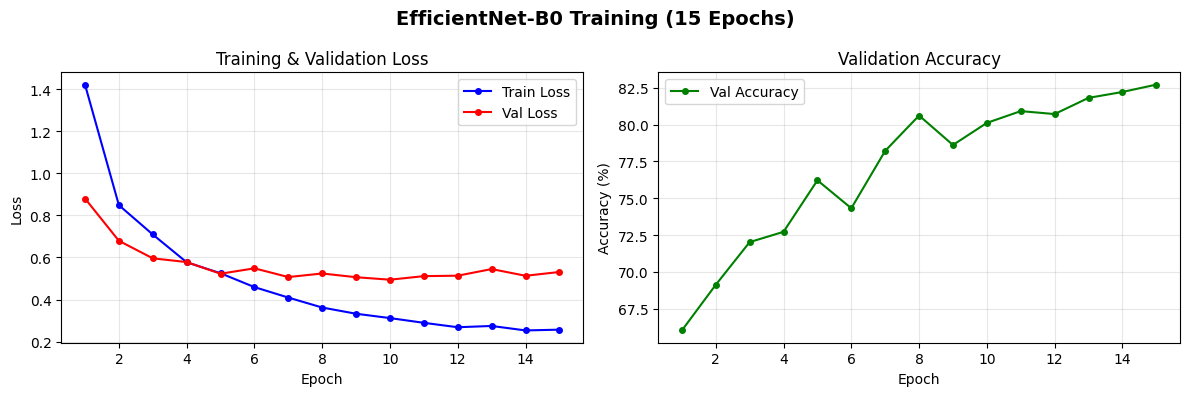

Saved: EfficientNet-B0_15epoch_curves.png


In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'{MODEL_NAME} Training (15 Epochs)',
             fontsize=14, fontweight='bold')
 
epochs_range = range(1, NUM_EPOCHS + 1)
 
ax1.plot(epochs_range, train_losses, 'b-o', markersize=4, label='Train Loss')
ax1.plot(epochs_range, val_losses,   'r-o', markersize=4, label='Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)
 
ax2.plot(epochs_range, val_accs, 'g-o', markersize=4, label='Val Accuracy')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Validation Accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig(f'{MODEL_NAME}_15epoch_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {MODEL_NAME}_15epoch_curves.png")

In [36]:
MODEL_NAME = 'EfficientNet-B0'
from torchvision.models import efficientnet_b0
model = efficientnet_b0()
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 7)
model = model.to(device)
model.load_state_dict(torch.load('EfficientNet-B0_best.pth'))
model.eval()
print("EfficientNet best model loaded!")

EfficientNet best model loaded!


In [37]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

label_names = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']

model.eval()
all_probs  = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_probs  = np.concatenate(all_probs,  axis=0)
all_labels = np.concatenate(all_labels, axis=0)

y_bin = label_binarize(all_labels, classes=list(range(7)))
auc_scores = {}
for i, name in enumerate(label_names):
    auc = roc_auc_score(y_bin[:, i], all_probs[:, i])
    auc_scores[name] = auc
    print(f'  {name:6s}: AUC = {auc:.4f}')

macro_auc = np.mean(list(auc_scores.values()))
print(f'\nMacro-avg AUC: {macro_auc:.4f}')

  nv    : AUC = 0.9658
  mel   : AUC = 0.9355
  bkl   : AUC = 0.9435
  bcc   : AUC = 0.9894
  akiec : AUC = 0.9895
  vasc  : AUC = 0.9993
  df    : AUC = 0.9998

Macro-avg AUC: 0.9747


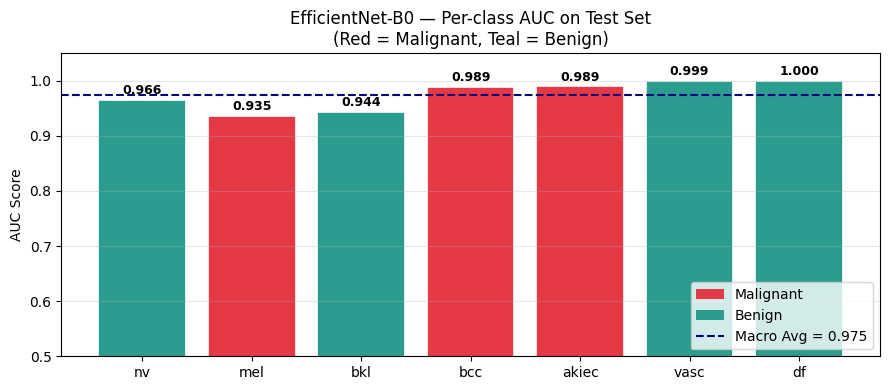

Saved: EfficientNet-B0_per_class_auc.png


In [38]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#E63946' if n in ['mel','bcc','akiec'] else '#2A9D8F'
          for n in label_names]

bars = ax.bar(label_names, [auc_scores[n] for n in label_names],
              color=colors, edgecolor='white', linewidth=1.2)

for bar, name in zip(bars, label_names):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{auc_scores[name]:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(macro_auc, color='navy', linestyle='--', linewidth=1.5)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('AUC Score')
ax.set_title(f'{MODEL_NAME} — Per-class AUC on Test Set\n'
             f'(Red = Malignant, Teal = Benign)')

legend_elements = [Patch(facecolor='#E63946', label='Malignant'),
                   Patch(facecolor='#2A9D8F', label='Benign'),
                   plt.Line2D([0],[0], color='navy', linestyle='--',
                              label=f'Macro Avg = {macro_auc:.3f}')]
ax.legend(handles=legend_elements, loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{MODEL_NAME}_per_class_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {MODEL_NAME}_per_class_auc.png")

EfficientNet-B0 loaded!


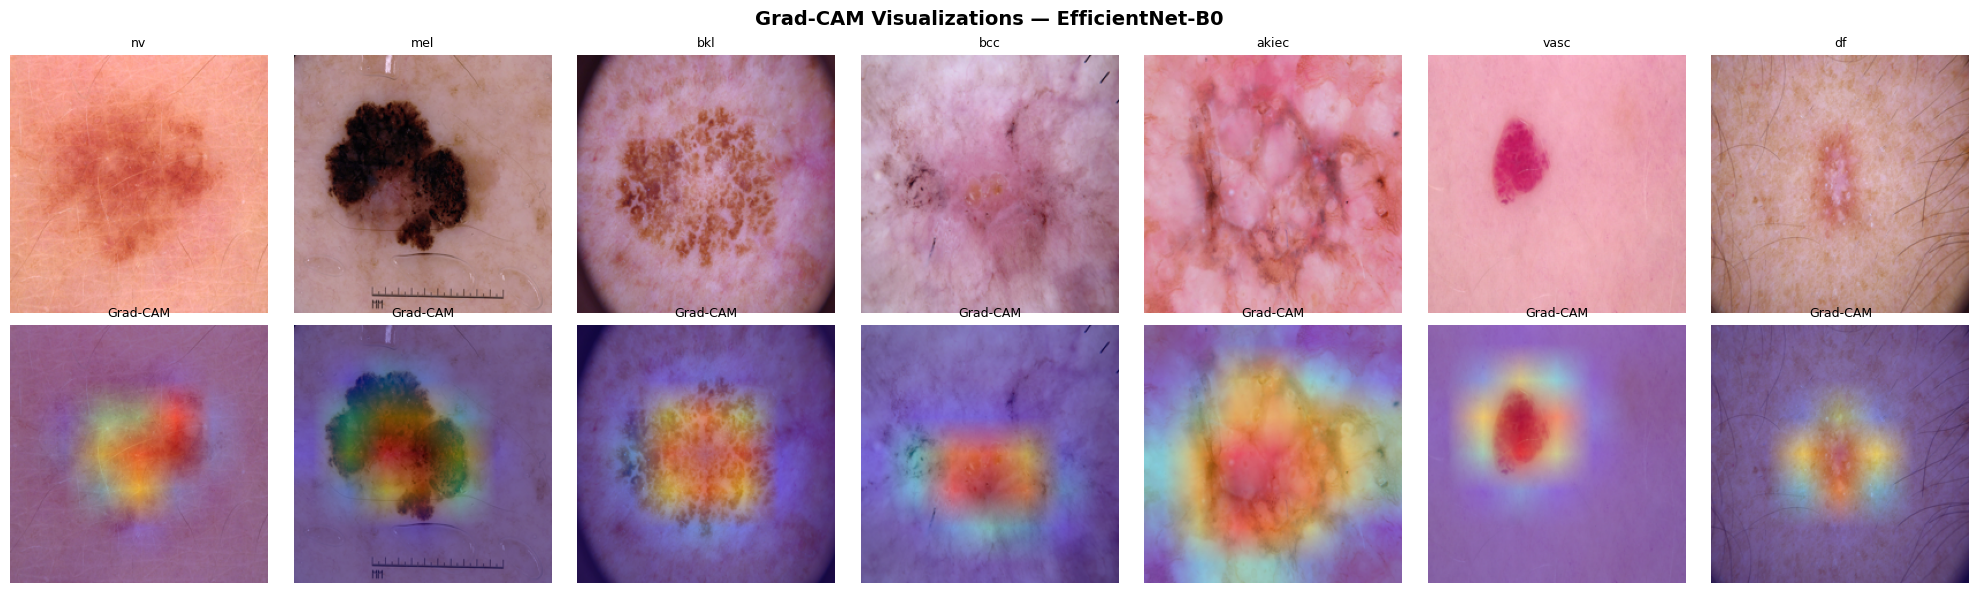

Saved: efficientnet_gradcam.png


In [39]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

# 加载EfficientNet最佳模型
model.load_state_dict(torch.load('EfficientNet-B0_best.pth'),
                      strict=False)  # strict=False避免key mismatch问题
model.eval()
print("EfficientNet-B0 loaded!")

# ── Grad-CAM class ─────────────────────────────────────────────────────
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx):
        self.model.eval()
        output = self.model(input_tensor)
        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0][class_idx] = 1
        output.backward(gradient=one_hot)
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam).squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

# EfficientNet-B0的target layer是最后一个features block
gradcam = GradCAM(model, model.features[-1])

# ── Transform ──────────────────────────────────────────────────────────
val_transform_224 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

label_names = ['nv','mel','bkl','bcc','akiec','vasc','df']

# ── Visualization ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 7, figsize=(20, 6))
fig.suptitle('Grad-CAM Visualizations — EfficientNet-B0',
             fontsize=14, fontweight='bold')

for i, label_idx in enumerate(range(7)):
    sample = test_df[test_df['label'] == label_idx].iloc[0]
    img_orig = Image.open(sample['path']).convert('RGB')
    img_resized = img_orig.resize((224, 224))

    inp = val_transform_224(img_orig).unsqueeze(0).to(device)
    cam = gradcam.generate(inp, label_idx)

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    heatmap = cv2.resize(heatmap, (224, 224))
    overlay = np.array(img_resized) * 0.6 + heatmap * 0.4
    overlay = np.uint8(overlay)

    axes[0][i].imshow(img_resized)
    axes[0][i].set_title(label_names[label_idx], fontsize=9)
    axes[0][i].axis('off')
    axes[1][i].imshow(overlay)
    axes[1][i].set_title('Grad-CAM', fontsize=9)
    axes[1][i].axis('off')

plt.tight_layout()
plt.savefig('efficientnet_gradcam.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: efficientnet_gradcam.png")